# Dataset Analysis for Eagle3 Training

Analyzes token-length distributions for the built-in speculators datasets (ShareGPT, UltraChat)
and new long-context datasets (>4096 tokens).

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
from datasets import load_dataset
from transformers import AutoTokenizer

warnings.filterwarnings("ignore")


plt.rcParams["figure.figsize"] = (12, 4)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

In [2]:
VERIFIER = "RedHatAI/Meta-Llama-3.1-8B-Instruct-FP8"
SAMPLE_SIZE = 5000

tokenizer = AutoTokenizer.from_pretrained(VERIFIER, trust_remote_code=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

In [3]:
def count_tokens(messages: list[dict]) -> int:
    return len(
        tokenizer.apply_chat_template(
            messages, tokenize=True, add_generation_prompt=False
        )
    )


def plot_histogram(lengths: list[int], title: str, n_total: int) -> None:
    arr = np.array(lengths)
    fig, ax = plt.subplots()
    ax.hist(arr, bins=80, color="#4C72B0", edgecolor="none", alpha=0.85)
    median = np.median(arr)
    ax.axvline(median, color="#C44E52", label=f"median = {median:.0f}")

    ax.set_title(f"{title}  (n={n_total:,})", fontsize=13)
    ax.set_xlabel("Tokens per conversation")
    ax.set_ylabel("Count")
    ax.legend(fontsize=10)

    plt.tight_layout()
    plt.show()

    print(f"  min={arr.min()} median={median:.0f} max={arr.max()}")

## Built-in Datasets

### ShareGPT — `Aeala/ShareGPT_Vicuna_unfiltered`

In [4]:
ROLE_MAP = {"human": "user", "gpt": "assistant", "system": "system"}


def sharegpt_to_messages(conv: list[dict]) -> list[dict] | None:
    messages = []
    for turn in conv:
        role = ROLE_MAP.get(turn.get("from", ""), None)
        text = turn.get("value", "")
        if role is None or not text:
            return None
        messages.append({"role": role, "content": text})
    return messages or None


ds_sharegpt = load_dataset("Aeala/ShareGPT_Vicuna_unfiltered", split="train")
print(f"Total examples: {len(ds_sharegpt):,}")

sample_sg = ds_sharegpt.shuffle(seed=0).select(
    range(min(SAMPLE_SIZE, len(ds_sharegpt)))
)

lengths_sg = []
for row in sample_sg:
    messages = sharegpt_to_messages(row["conversations"])
    if messages is None:
        continue
    try:
        lengths_sg.append(count_tokens(messages))
    except Exception:
        pass

Total examples: 120,675


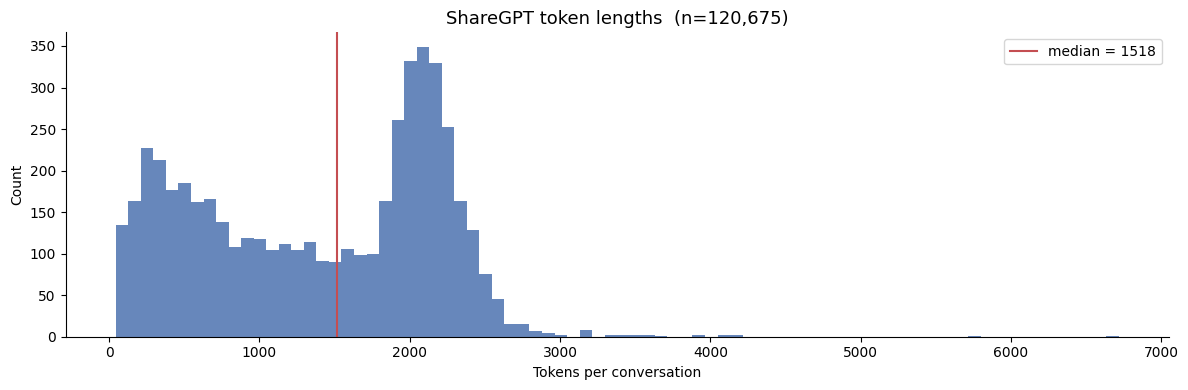

  min=44 median=1518 max=6716


In [5]:
plot_histogram(lengths_sg, "ShareGPT token lengths", len(ds_sharegpt))

### UltraChat — `HuggingFaceH4/ultrachat_200k`

In [6]:
ds_ultrachat = load_dataset("HuggingFaceH4/ultrachat_200k", split="train_sft")
print(f"Total examples: {len(ds_ultrachat):,}")

sample_uc = ds_ultrachat.shuffle(seed=0).select(
    range(min(SAMPLE_SIZE, len(ds_ultrachat)))
)

lengths_uc = []
for row in sample_uc:
    messages = row["messages"]
    try:
        lengths_uc.append(count_tokens(messages))
    except Exception:
        pass

Total examples: 207,865


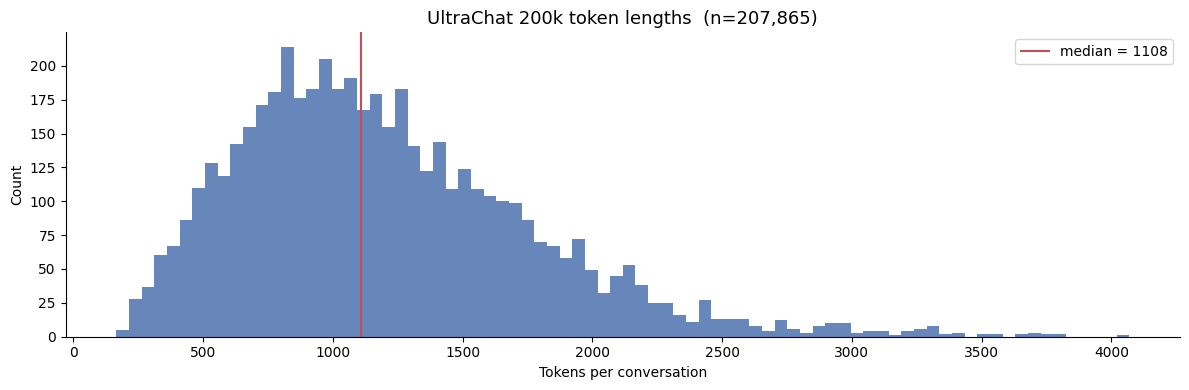

  min=166 median=1108 max=4069


In [7]:
plot_histogram(lengths_uc, "UltraChat 200k token lengths", len(ds_ultrachat))

## Long-Context Dataset Suggestions (> 4096 tokens)

The built-in datasets are mostly short (ShareGPT median ~1–2k tokens, UltraChat ~2–3k).
To train the speculator on long-context sequences the following datasets can be used instead:

| Dataset | HF ID | Size | Avg tokens | Notes |
|---|---|---|---|---|
| **LongAlpaca-16k** | `Yukang/LongAlpaca-16k` | ~52k | ~6–10k | Instruction-following, extends Alpaca to 16k ctx |
| **LongAlign-10k** | `THUDM/LongAlign-10k` | ~10k | ~8–20k | Purpose-built long-ctx alignment, up to 64k tokens |

### LongAlpaca-16k — `Yukang/LongAlpaca-16k`

In [4]:
ds_longalpaca = load_dataset("Yukang/LongAlpaca-16k-length", split="train")
print(f"Total examples: {len(ds_longalpaca):,}")
print("Columns:", ds_longalpaca.column_names)
# ds_longalpaca[0]

Total examples: 6,284
Columns: ['output', 'instruction', 'file']


In [9]:
def longalpaca_to_messages(row: dict) -> list[dict]:
    user_text = row["instruction"]
    if row.get("input", "").strip():
        user_text = f"{user_text}\n\n{row['input']}"
    return [
        {"role": "user", "content": user_text},
        {"role": "assistant", "content": row["output"]},
    ]


sample_la = ds_longalpaca.shuffle(seed=0).select(
    range(min(SAMPLE_SIZE, len(ds_longalpaca)))
)

lengths_la = []
for row in sample_la:
    try:
        lengths_la.append(count_tokens(longalpaca_to_messages(row)))
    except Exception:
        pass

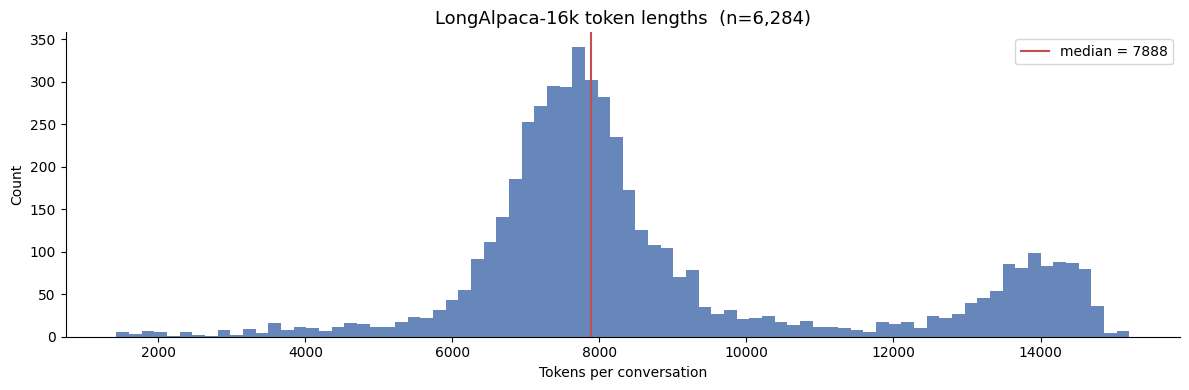

  min=1429 median=7888 max=15208


In [10]:
plot_histogram(lengths_la, "LongAlpaca-16k token lengths", len(ds_longalpaca))

### LongAlign-10k — `THUDM/LongAlign-10k`

[Site](https://huggingface.co/datasets/zai-org/LongAlign-10k/blob/main/README.md)

In [5]:
ds_longalign = load_dataset("THUDM/LongAlign-10k", split="train")
print(f"Total examples: {len(ds_longalign):,}")
print("Columns:", ds_longalign.column_names)
# ds_longalign[0]

README.md: 0.00B [00:00, ?B/s]

long.jsonl:   0%|          | 0.00/655M [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

Total examples: 9,888
Columns: ['dataset', 'id', 'messages', 'length']


In [12]:
def longalign_to_messages(row: dict) -> list[dict] | None:
    messages = []
    for turn in row["messages"]:
        role = turn.get("role", "")
        content = turn.get("content", "")
        if role not in ("user", "assistant", "system") or not content:
            return None
        messages.append({"role": role, "content": content})
    return messages or None


lengths_lon = []
for row in ds_longalign:
    messages = longalign_to_messages(row)
    if messages is None:
        continue
    try:
        lengths_lon.append(count_tokens(messages))
    except Exception:
        pass

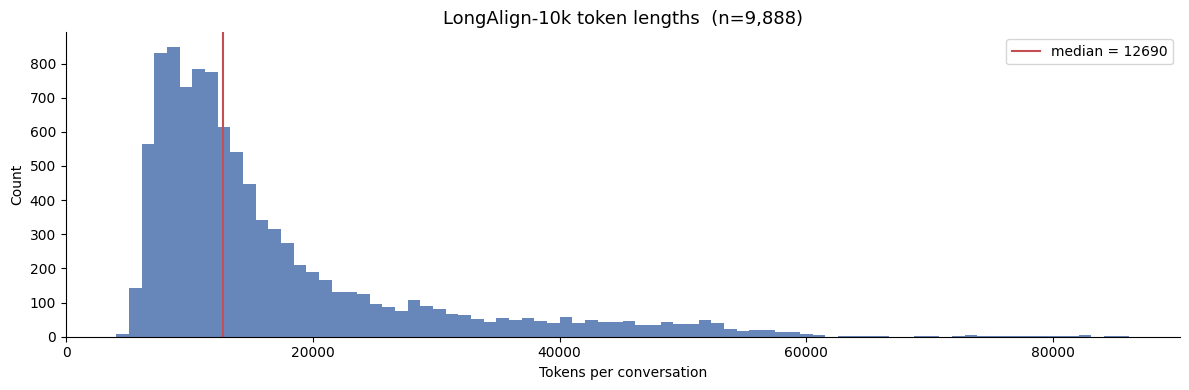

  min=4068 median=12690 max=86175


In [13]:
plot_histogram(lengths_lon, "LongAlign-10k token lengths", len(ds_longalign))

## Summary Comparison

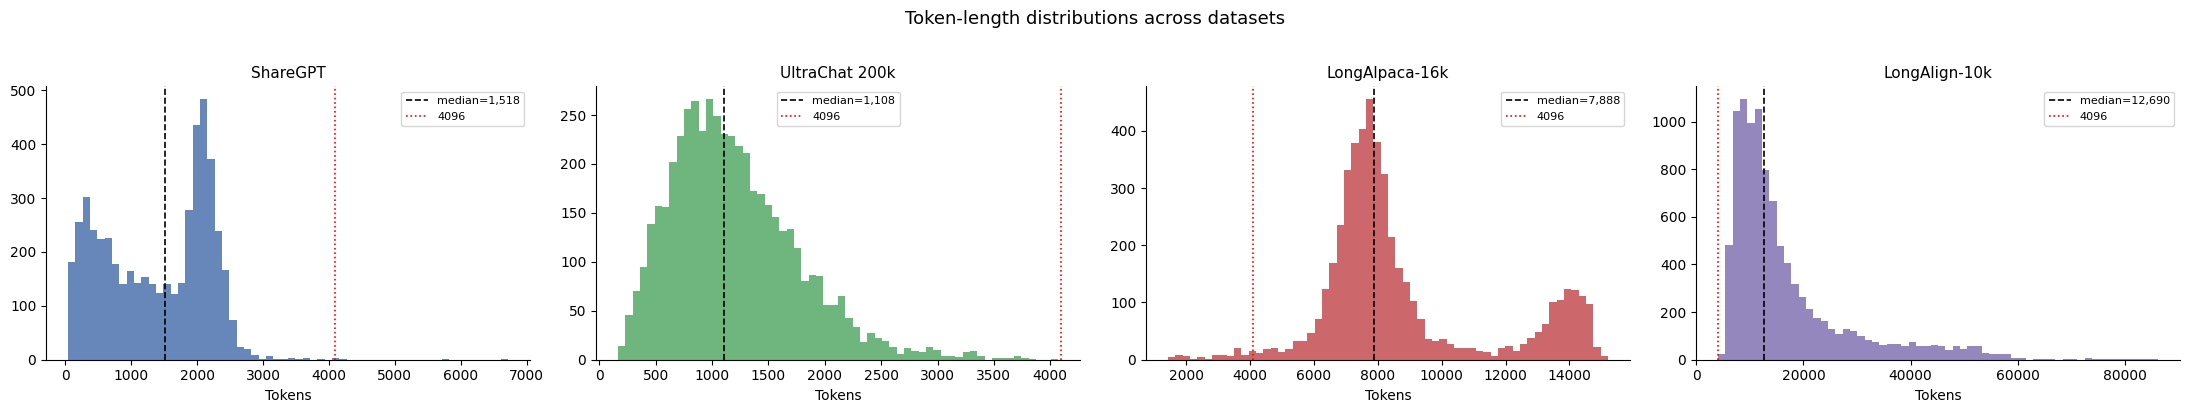


Dataset                     n   median    >4096
------------------------------------------------------------
ShareGPT                 5000     1518     0.1%
UltraChat 200k           5000     1108     0.0%
LongAlpaca-16k           5000     7888    98.2%
LongAlign-10k            9888    12690   100.0%


In [14]:
datasets_summary = {
    "ShareGPT": lengths_sg,
    "UltraChat 200k": lengths_uc,
    "LongAlpaca-16k": lengths_la,
    "LongAlign-10k": lengths_lon,
}

fig, axes = plt.subplots(1, len(datasets_summary), figsize=(22, 4), sharey=False)
colors = ["#4C72B0", "#55A868", "#C44E52", "#8172B2"]

for ax, (name, lengths), color in zip(axes, datasets_summary.items(), colors):
    arr = np.array(lengths)
    ax.hist(arr, bins=60, color=color, edgecolor="none", alpha=0.85)
    ax.axvline(
        np.median(arr),
        color="black",
        linestyle="--",
        linewidth=1.2,
        label=f"median={np.median(arr):,.0f}",
    )
    ax.axvline(4096, color="red", linestyle=":", linewidth=1.2, label="4096")
    ax.set_title(name, fontsize=11)
    ax.set_xlabel("Tokens")
    ax.legend(fontsize=8)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

fig.suptitle("Token-length distributions across datasets", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(f"\n{'Dataset':<20} {'n':>8} {'median':>8} {'>4096':>8}")
print("-" * 60)
for name, lengths in datasets_summary.items():
    arr = np.array(lengths)
    frac_long = (arr > 4096).mean() * 100
    print(f"{name:<20} {len(arr):>8} {np.median(arr):>8.0f} {frac_long:>7.1f}%")